In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

DATA_PATH = "/content/wheat_yield_RONI_climate_irrigation_merged.csv"

In [ ]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(12418, 22)


,dist_code,crop_year,state_code,state_name,dist_name,rice_area,rice_production,rice_yield,wheat_area,wheat_production,wheat_yield,RONI_OND_prevyear,RONI_NDJ_prevyear,RONI_DJF,RONI_JFM,RONI_growing_season_mean,ENSO_phase_DJF,rabi_precip_mm,rabi_tmax_c,gross_irrigated_area,gross_cropped_area,irrigation_ratio
0,1,1978,14,Chhattisgarh,Durg,612.5,362.2,591.35,48.7,25.6,525.67,1.1,1.1,0.9,0.6,0.925,El Nino,NaN,NaN,NaN,NaN,NaN
1,1,1979,14,Chhattisgarh,Durg,616.8,330.6,535.99,44.6,17.8,399.10,0.2,0.2,0.2,0.2,0.200,Neutral,NaN,NaN,NaN,NaN,NaN
2,1,1980,14,Chhattisgarh,Durg,634.9,515.6,812.10,44.1,33.6,761.90,0.5,0.7,0.6,0.5,0.575,El Nino,NaN,NaN,NaN,NaN,NaN
3,1,1981,14,Chhattisgarh,Durg,630.0,506.9,804.60,41.5,23.6,568.67,0.2,0.2,0.0,-0.3,0.025,Neutral,NaN,NaN,NaN,NaN,NaN
4,1,1982,14,Chhattisgarh,Durg,627.9,513.3,817.49,41.1,23.9,581.51,-0.2,0.0,0.1,0.3,0.050,Neutral,NaN,NaN,NaN,NaN,NaN


In [ ]:
# %% [2] BASIC EDA -- structure, dtypes, missingness
print(df.info())
print("\nMissing % per column:")
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))

print("\nENSO phase distribution:")
print(df["ENSO_phase_DJF"].value_counts())

print("\nYear range:", df["crop_year"].min(), "-", df["crop_year"].max())
print("States:", df["state_name"].nunique(), " Districts:", df["dist_name"].nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12418 entries, 0 to 12417
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dist_code                 12418 non-null  int64  
 1   crop_year                 12418 non-null  int64  
 2   state_code                12418 non-null  int64  
 3   state_name                12418 non-null  object 
 4   dist_name                 12418 non-null  object 
 5   rice_area                 12418 non-null  float64
 6   rice_production           12418 non-null  float64
 7   rice_yield                12418 non-null  float64
 8   wheat_area                12418 non-null  float64
 9   wheat_production          12418 non-null  float64
 10  wheat_yield               12418 non-null  float64
 11  RONI_OND_prevyear         12418 non-null  float64
 12  RONI_NDJ_prevyear         12418 non-null  float64
 13  RONI_DJF                  12418 non-null  float64
 14  RONI_J

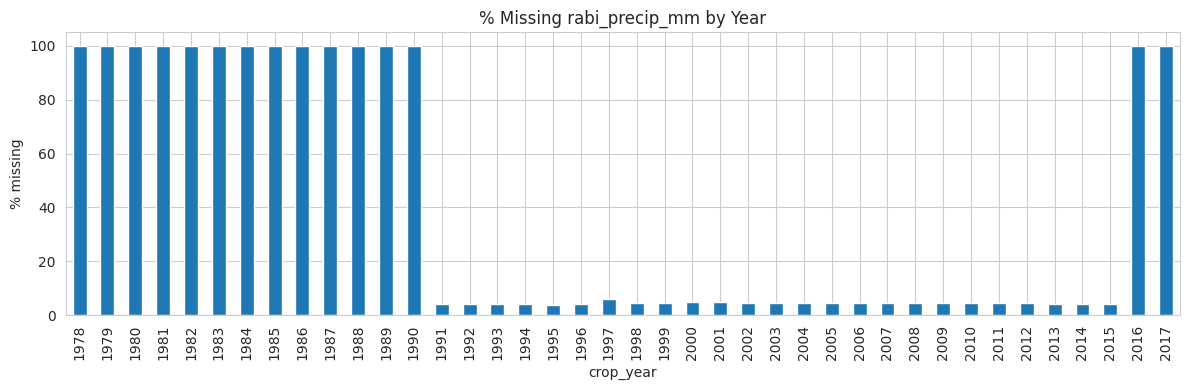

In [ ]:
# %% [3] MISSINGNESS PATTERN CHECK (important before imputing!)
missing_by_year = df.groupby("crop_year")["rabi_precip_mm"].apply(lambda x: x.isna().mean() * 100)
plt.figure(figsize=(12, 4))
missing_by_year.plot(kind="bar")
plt.title("% Missing rabi_precip_mm by Year")
plt.ylabel("% missing")
plt.tight_layout()
plt.show()
# Insight: climate columns are ~100% missing outside 1991-2015, and only
# ~4-6% missing within that window. So we restrict modeling to 1991-2015.

In [ ]:
# %% [4] FILTER TO RELIABLE DATA WINDOW
df_model = df[(df["crop_year"] >= 1991) & (df["crop_year"] <= 2015)].copy()
print("Rows before filter:", len(df), " after filter:", len(df_model))
print("Remaining missing % (climate cols):")
print((df_model[["rabi_precip_mm", "rabi_tmax_c", "gross_irrigated_area",
                  "gross_cropped_area", "irrigation_ratio"]].isna().mean() * 100).round(1))

Rows before filter: 12418  after filter: 7755
Remaining missing % (climate cols):
rabi_precip_mm           4.5
rabi_tmax_c              4.5
gross_irrigated_area    11.3
gross_cropped_area       5.4
irrigation_ratio        12.0
dtype: float64


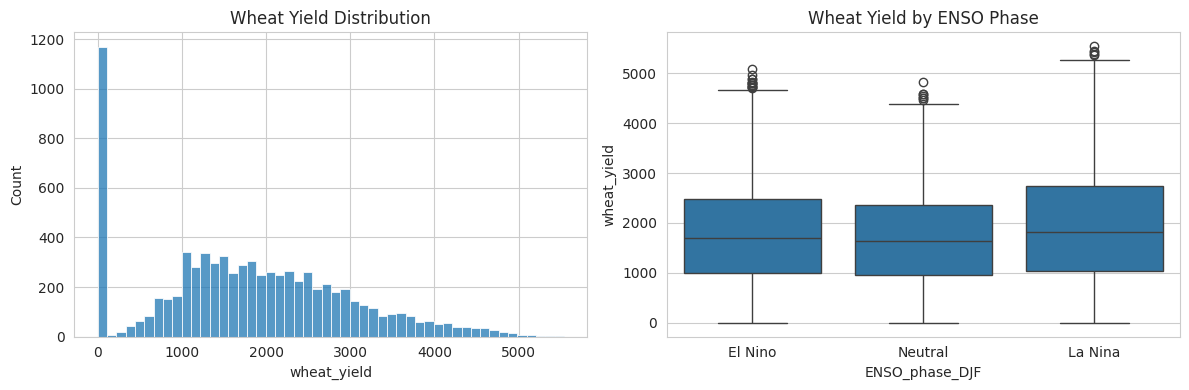

                       mean   median          std  count
ENSO_phase_DJF                                          
El Nino         1733.292833  1693.69  1135.977529   3099
La Nina         1881.803440  1810.02  1240.001110   3413
Neutral         1654.677377  1633.97  1094.293651   1243


In [ ]:
# %% [5] TARGET DISTRIBUTION + OUTLIER CHECK
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_model["wheat_yield"], bins=50, ax=axes[0])
axes[0].set_title("Wheat Yield Distribution")
sns.boxplot(x="ENSO_phase_DJF", y="wheat_yield", data=df_model, ax=axes[1])
axes[1].set_title("Wheat Yield by ENSO Phase")
plt.tight_layout()
plt.show()

print(df_model.groupby("ENSO_phase_DJF")["wheat_yield"].agg(["mean", "median", "std", "count"]))


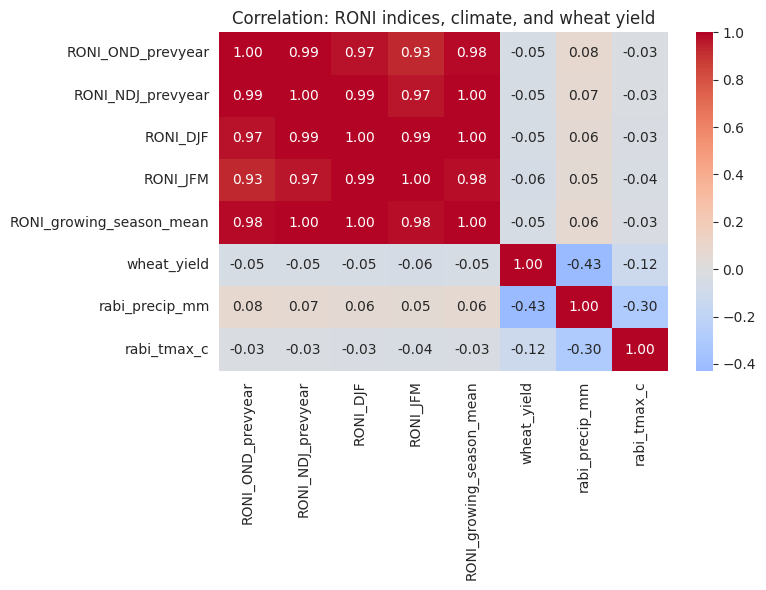

In [ ]:
# %% [6] ENSO / RONI CORRELATION WITH YIELD
enso_cols = ["RONI_OND_prevyear", "RONI_NDJ_prevyear", "RONI_DJF",
             "RONI_JFM", "RONI_growing_season_mean"]
corr = df_model[enso_cols + ["wheat_yield", "rabi_precip_mm", "rabi_tmax_c"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: RONI indices, climate, and wheat yield")
plt.tight_layout()
plt.show()

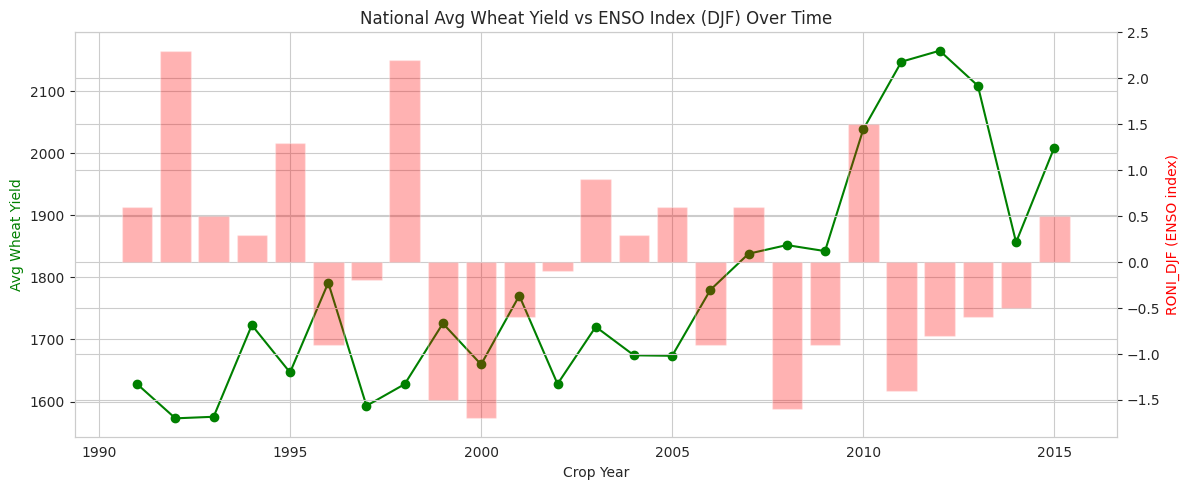

In [ ]:
# %% [7] TREND OVER TIME: national avg yield vs RONI_DJF
yearly = df_model.groupby("crop_year").agg(
    avg_yield=("wheat_yield", "mean"),
    avg_roni_djf=("RONI_DJF", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(yearly["crop_year"], yearly["avg_yield"], color="green", marker="o", label="Avg Wheat Yield")
ax2.bar(yearly["crop_year"], yearly["avg_roni_djf"], alpha=0.3, color="red", label="RONI_DJF")
ax1.set_ylabel("Avg Wheat Yield", color="green")
ax2.set_ylabel("RONI_DJF (ENSO index)", color="red")
ax1.set_xlabel("Crop Year")
plt.title("National Avg Wheat Yield vs ENSO Index (DJF) Over Time")
plt.tight_layout()
plt.show()

In [ ]:
# %% [8] FEATURE ENGINEERING
data = df_model.copy()

# 8.1 Fill small remaining gaps (~4-6%) with state-year median, then global median
for col in ["rabi_precip_mm", "rabi_tmax_c", "gross_irrigated_area",
            "gross_cropped_area", "irrigation_ratio"]:
    data[col] = data.groupby("state_name")[col].transform(lambda x: x.fillna(x.median()))
    data[col] = data[col].fillna(data[col].median())

# 8.2 One-hot encode ENSO phase
data = pd.get_dummies(data, columns=["ENSO_phase_DJF"], prefix="ENSO")

# 8.3 District-level historical baseline yield (mean yield excluding current row's year
#     would be ideal to avoid leakage; here we use an expanding mean per district over time)
data = data.sort_values(["dist_code", "crop_year"])
data["dist_hist_avg_yield"] = (
    data.groupby("dist_code")["wheat_yield"]
    .apply(lambda x: x.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)
# first occurrence of a district has no history -> fill with state mean
data["dist_hist_avg_yield"] = data["dist_hist_avg_yield"].fillna(
    data.groupby("state_name")["wheat_yield"].transform("mean")
)

# 8.4 Interaction features
data["heat_x_ronijfm"] = data["rabi_tmax_c"] * data["RONI_JFM"]
data["irrig_x_roniDJF"] = data["irrigation_ratio"] * data["RONI_DJF"]
data["precip_x_roniDJF"] = data["rabi_precip_mm"] * data["RONI_DJF"]

# 8.5 Rice area/production kept as context features (crop diversification proxy)
# 8.6 Drop columns that would leak the target or are pure IDs
drop_cols = ["dist_code", "state_code", "dist_name", "state_name",
             "wheat_production", "rice_production"]  # production ~ area*yield, leaky
data_model = data.drop(columns=drop_cols)

print(data_model.columns.tolist())
print(data_model.shape)

['crop_year', 'rice_area', 'rice_yield', 'wheat_area', 'wheat_yield', 'RONI_OND_prevyear', 'RONI_NDJ_prevyear', 'RONI_DJF', 'RONI_JFM', 'RONI_growing_season_mean', 'rabi_precip_mm', 'rabi_tmax_c', 'gross_irrigated_area', 'gross_cropped_area', 'irrigation_ratio', 'ENSO_El Nino', 'ENSO_La Nina', 'ENSO_Neutral', 'dist_hist_avg_yield', 'heat_x_ronijfm', 'irrig_x_roniDJF', 'precip_x_roniDJF']
(7755, 22)


In [ ]:
# %% [9] TRAIN/TEST SPLIT -- TIME-BASED (avoid leakage across years)
TRAIN_END_YEAR = 2010

train_df = data_model[data_model["crop_year"] <= TRAIN_END_YEAR]
test_df = data_model[data_model["crop_year"] > TRAIN_END_YEAR]

FEATURES = [c for c in data_model.columns if c not in ["wheat_yield", "crop_year"]]
TARGET = "wheat_yield"

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train years:", train_df["crop_year"].min(), "-", train_df["crop_year"].max())
print("Test years:", test_df["crop_year"].min(), "-", test_df["crop_year"].max())

Train: (6203, 20)  Test: (1552, 20)
Train years: 1991 - 2010
Test years: 2011 - 2015


In [ ]:
# %% [10] MODEL 1 -- RANDOM FOREST
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}\n")
    return mae, rmse, r2

evaluate(y_test, rf_pred, "Random Forest")

--- Random Forest ---
MAE  : 378.47
RMSE : 542.66
R2   : 0.8330



(378.46556508106295, np.float64(542.6578655184376), 0.8329789774443728)

In [ ]:
# %% [11] MODEL 2 -- XGBOOST
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_pred = xgb_model.predict(X_test)
evaluate(y_test, xgb_pred, "XGBoost")

--- XGBoost ---
MAE  : 382.11
RMSE : 539.30
R2   : 0.8350



(382.1117581199924, np.float64(539.3048358831834), 0.8350366137550009)

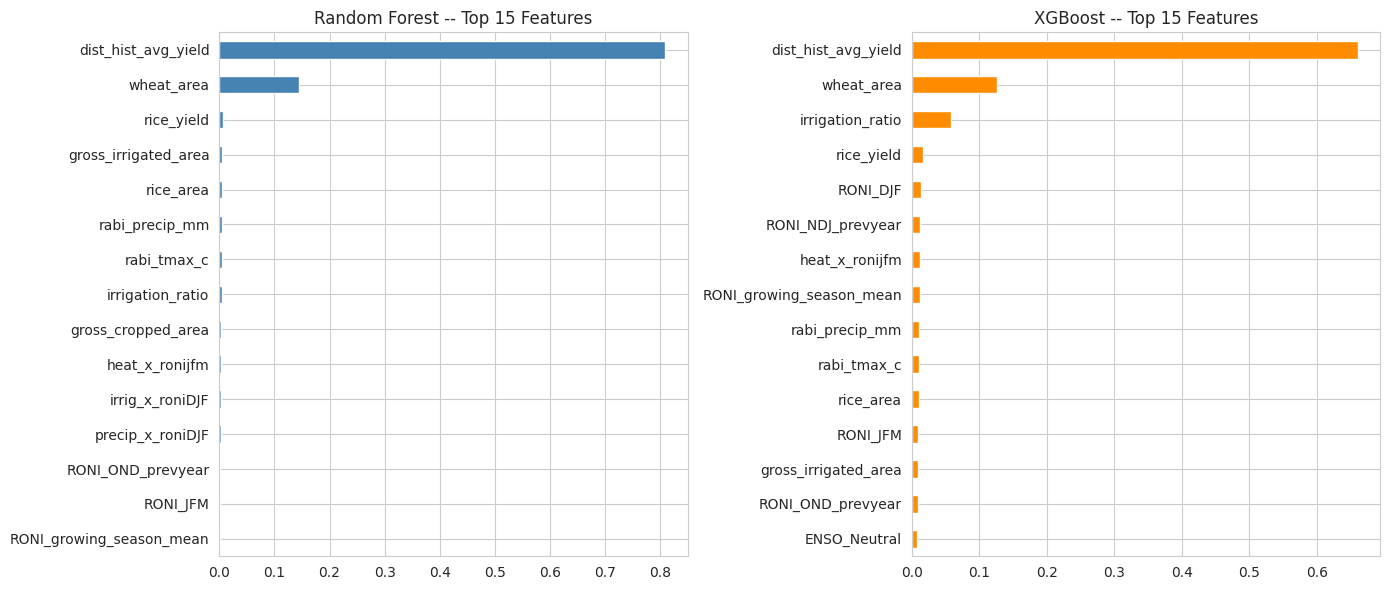

In [ ]:
# %% [12] FEATURE IMPORTANCE COMPARISON
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_imp.head(15).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Random Forest -- Top 15 Features")

xgb_imp.head(15).plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].invert_yaxis()
axes[1].set_title("XGBoost -- Top 15 Features")
plt.tight_layout()
plt.show()

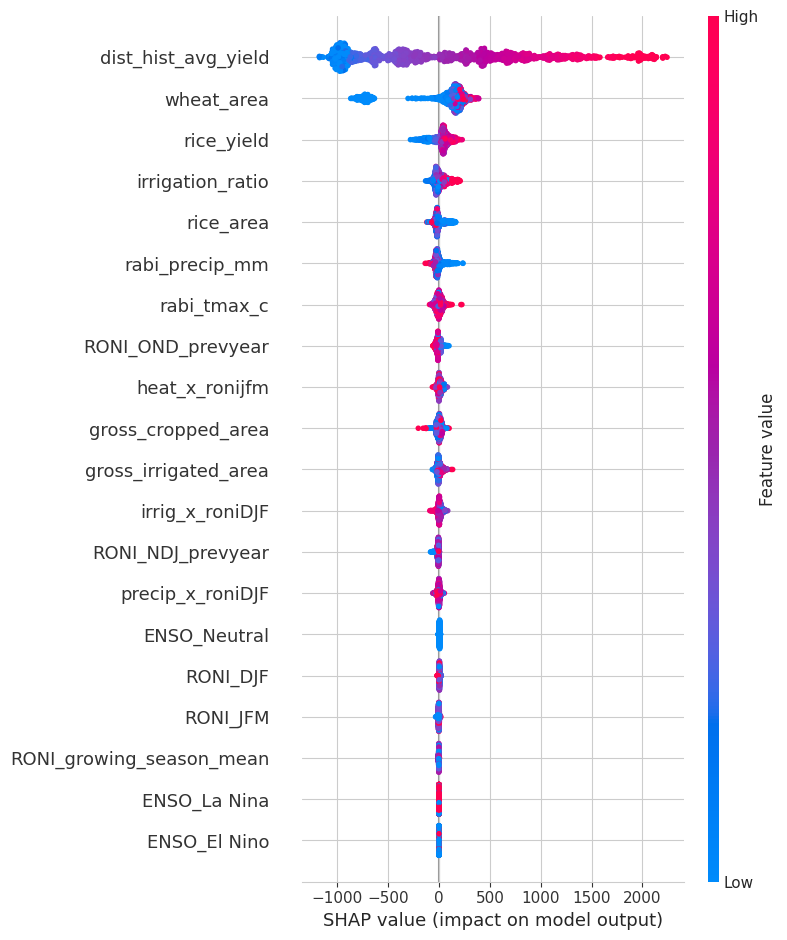

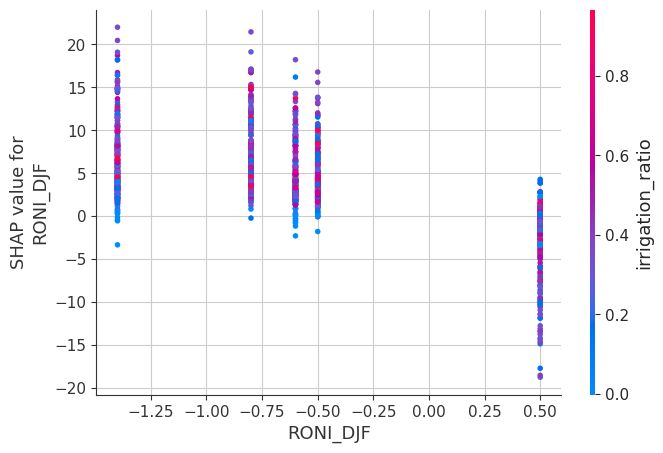

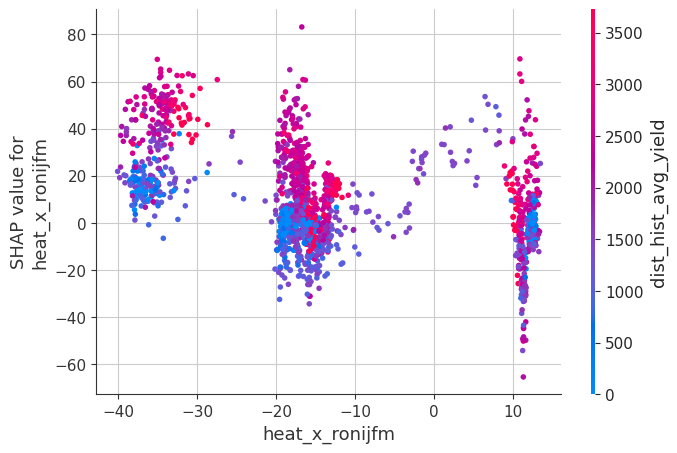

           Model         MAE        RMSE        R2
0  Random Forest  378.465565  542.657866  0.832979
1        XGBoost  382.111758  539.304836  0.835037


In [ ]:
# %% [13] SHAP -- EXPLAIN THE ENSO EFFECT SPECIFICALLY (XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# 13.1 Overall summary plot
shap.summary_plot(shap_values, X_test, show=True)

# 13.2 Focus: dependence plot for RONI_DJF (the core ENSO signal for wheat season)
shap.dependence_plot("RONI_DJF", shap_values, X_test, interaction_index="irrigation_ratio")
# Reading this: x-axis = ENSO index value (negative = La Nina, positive = El Nino),
# y-axis = SHAP value (impact on predicted yield), color = irrigation ratio.
# If irrigated (high color) districts show flatter SHAP lines across RONI_DJF,
# that confirms irrigation buffers the El Nino yield penalty.

# 13.3 Dependence plot for the heat x ENSO interaction feature
shap.dependence_plot("heat_x_ronijfm", shap_values, X_test)

# %% [14] MODEL COMPARISON TABLE
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mean_absolute_error(y_test, rf_pred), mean_absolute_error(y_test, xgb_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, rf_pred)), np.sqrt(mean_squared_error(y_test, xgb_pred))],
    "R2": [r2_score(y_test, rf_pred), r2_score(y_test, xgb_pred)]
})
print(results)

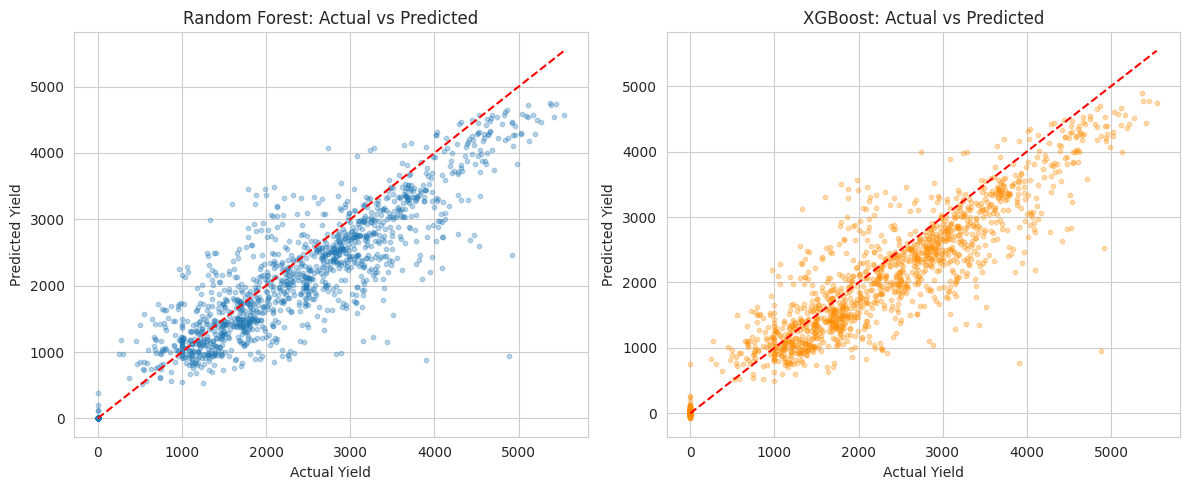

In [ ]:
# %% [15] SANITY CHECK -- PREDICTED VS ACTUAL SCATTER
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, rf_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].set_xlabel("Actual Yield")
axes[0].set_ylabel("Predicted Yield")

axes[1].scatter(y_test, xgb_pred, alpha=0.3, s=10, color="darkorange")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title("XGBoost: Actual vs Predicted")
axes[1].set_xlabel("Actual Yield")
axes[1].set_ylabel("Predicted Yield")
plt.tight_layout()
plt.show()
